# Lab 1: Классификация цвета автомобиля (DVM)

**Датасет:** DVM — [Deep Visual Marketing](https://deepvisualmarketing.github.io/), фронтальные виды автомобилей.

**Задачи:**
1. Реализовать классификатор **с нуля** и обучить на DVM для предсказания цвета.
2. Взять **2 предобученных** классификатора из torchvision и дообучить на DVM.
3. Оценить качество по **F1_macro** (цель: F1_macro > 0.8).
4. Сравнить все классификаторы и сделать выводы.

## 1. Импорты и конфигурация

In [18]:
import os
import random
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights, DenseNet169_Weights
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [19]:
# Формат имени: Brand$$Model$$Year$$Color$$...$$image_N.jpg
DATA_ROOT = 'data'
CHECKPOINT_DIR = '.'
LOG_FOLDER = 'logs'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_CUSTOM = 15
EPOCHS_FINETUNE = 10
LR = 1e-3
SEED = 42
TRAIN_RATIO, VAL_RATIO = 0.7, 0.15

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
set_seed()

## 2. Загрузка и предобработка данных

In [20]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [21]:
def collect_images_by_color(root):
    root = os.path.abspath(root)
    samples = []
    for brand in sorted(os.listdir(root)):
        brand_path = os.path.join(root, brand)
        if not os.path.isdir(brand_path) or brand.startswith('.'):
            continue
        for year in os.listdir(brand_path):
            year_path = os.path.join(brand_path, year)
            if not os.path.isdir(year_path):
                continue
            for fname in os.listdir(year_path):
                if not (fname.lower().endswith('.jpg') or fname.lower().endswith('.jpeg') or fname.lower().endswith('.png')):
                    continue
                parts = fname.split('$$')
                if len(parts) >= 4:
                    color = parts[3].strip()
                    path = os.path.join(year_path, fname)
                    samples.append((path, color))
    return samples

samples = collect_images_by_color(DATA_ROOT)

EXCLUDE_COLORS = {'Unlisted'}
samples = [(p, c) for p, c in samples if c not in EXCLUDE_COLORS]
print('Найдено изображений:', len(samples))
if len(samples) == 0:
    raise FileNotFoundError(f'В папке {DATA_ROOT} не найдено изображений в формате Brand/Year/...$$Color$$....jpg')

all_colors = sorted(set(s for _, s in samples))
class_names = all_colors
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)
labels = np.array([class_to_idx[c] for _, c in samples])
paths = np.array([p for p, _ in samples])

MIN_SAMPLES_PER_CLASS = 500
MAX_SAMPLES_PER_CLASS = 10000
np.random.seed(SEED)
path_list, label_list = [], []
for cls_idx in range(num_classes):
    mask = labels == cls_idx
    idx = np.where(mask)[0]
    if len(idx) < MIN_SAMPLES_PER_CLASS:
        continue
    if len(idx) > MAX_SAMPLES_PER_CLASS:
        idx = np.random.choice(idx, MAX_SAMPLES_PER_CLASS, replace=False)
    path_list.extend(paths[idx])
    label_list.extend(labels[idx])
paths = np.array(path_list)
labels = np.array(label_list)

remaining = np.unique(labels)
class_names = [class_names[i] for i in remaining]
class_to_idx = {c: i for i, c in enumerate(class_names)}
old_to_new = {int(o): new for new, o in enumerate(remaining)}
labels = np.array([old_to_new[int(o)] for o in labels])
num_classes = len(class_names)

print('После фильтрации: классов', num_classes, ', примеров', len(paths))
print('Классы (цвета):', class_names)

Найдено изображений: 60311
После фильтрации: классов 11 , примеров 54731
Классы (цвета): ['Beige', 'Black', 'Blue', 'Brown', 'Green', 'Grey', 'Orange', 'Red', 'Silver', 'White', 'Yellow']


In [22]:
train_idx, rest_idx = train_test_split(np.arange(len(paths)), test_size=(1 - TRAIN_RATIO), stratify=labels, random_state=SEED)
val_ratio_adj = VAL_RATIO / (1 - TRAIN_RATIO)
val_idx, test_idx = train_test_split(rest_idx, test_size=(1 - val_ratio_adj), stratify=labels[rest_idx], random_state=SEED)

class ImagePathsDataset(Dataset):
    """Датасет по списку путей и меток с применением transform."""
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]

train_ds = ImagePathsDataset(paths[train_idx], labels[train_idx], transform=train_tf)
val_ds = ImagePathsDataset(paths[val_idx], labels[val_idx], transform=val_tf)
test_ds = ImagePathsDataset(paths[test_idx], labels[test_idx], transform=val_tf)
print('Train:', len(train_ds), 'Val:', len(val_ds), 'Test:', len(test_ds))

Train: 38311 Val: 8209 Test: 8211


In [23]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 3. Классификатор с нуля: ResNet18

In [24]:
def conv3x3(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)

def conv1x1(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)

class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, stride)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = conv3x3(out_ch, out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(conv1x1(in_ch, out_ch, stride), nn.BatchNorm2d(out_ch))

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

class CustomResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_ch = 64
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
            self._make_layer(64, 2, stride=1),
            self._make_layer(128, 2, stride=2),
            self._make_layer(256, 2, stride=2),
            self._make_layer(512, 2, stride=2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_ch, blocks, stride=1):
        layers = [BasicBlock(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [25]:
model_custom = CustomResNet(num_classes=num_classes).to(device)
n_params = sum(p.numel() for p in model_custom.parameters())
print(f'Custom ResNet: параметров {n_params:,}')

Custom ResNet: параметров 11,182,155


In [26]:
def run_epoch_detailed(phase, model, loader, criterion, optimizer, device):
    if phase == 'train':
        model.train()
    else:
        model.eval()
    running_loss = 0.0
    running_corrects = 0
    all_preds, all_labels = [], []
    n_total = 0
    pbar = tqdm(loader, desc=f'  {phase}', leave=True)
    for images, labels_b in pbar:
        bz = images.shape[0]
        n_total += bz
        images = images.to(device, non_blocking=True)
        labels_b = labels_b.to(device, non_blocking=True)
        if phase == 'train':
            optimizer.zero_grad()
        with torch.set_grad_enabled(phase == 'train'):
            outputs = model(images)
            loss = criterion(outputs, labels_b)
            if phase == 'train':
                loss.backward()
                optimizer.step()
        preds = outputs.argmax(dim=1)
        corrects = (preds == labels_b).sum().item()
        running_loss += loss.item() * bz
        running_corrects += corrects
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels_b.cpu().numpy())
        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            'Corrects': f'{corrects}/{bz}',
            'Accuracy': f'{100.0 * corrects / bz:.2f}%'
        })
    epoch_loss = running_loss / n_total
    epoch_acc = running_corrects / n_total
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    conf = confusion_matrix(all_labels, all_preds)
    return epoch_loss, epoch_acc, f1_macro, conf

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

def get_f1_macro(model, loader, device):
    preds, labels = evaluate(model, loader, device)
    return f1_score(labels, preds, average='macro', zero_division=0)

Training model (Custom ResNet) with params:
Optim: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Criterion: CrossEntropyLoss()
Epoch 1/15
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [04:04<00:00,  4.89it/s, Loss=1.134850, Corrects=4/7, Accuracy=57.14%]


Calculating metrics...
train loss: 1.037698, acc: 0.629767, f1_macro: 0.432174
Confusion matrix:
[[   5   17    6    4    1  105    0    8  201   66    7]
 [   0 4800  864    1    2 1150    0   61   69   52    1]
 [   0 1387 3522    0    3  713    0   24  219   69    1]
 [   0  171   29   10    1  268    4   58   81   12    4]
 [   1  169   76    1   10   97    0    6   80   81   23]
 [   4 1544  703    9    1 3252    1   52  856  203    7]
 [   0   15    3    2    0    9   16  313    5    2   26]
 [   0   98   12   10    0   54   10 4039   15   17   11]
 [   4   97  132    1    2  883    1   27 2865 1417   10]
 [   2   38   40    0    3  148    1   21  982 5329   12]
 [   2    4    3    3    3   15    7   95   28   28  279]]
--- Cur phase: val


  val: 100%|███████████████████████████████████| 257/257 [00:19<00:00, 13.51it/s, Loss=1.389064, Corrects=9/17, Accuracy=52.94%]


Calculating metrics...
val loss: 0.843311, acc: 0.703374, f1_macro: 0.525819
Confusion matrix:
[[   1    1    1    0    2   16    0    0   56   10    3]
 [   0  933  154    1   65  322    0    2   11    9    3]
 [   0  138 1024    0   13   62    0    1   27    7    0]
 [   6   17    2    5    4   78    5    1   12    3    4]
 [   1   23   19    0   23   10    0    0    8   17   16]
 [   2  144  290    1   22  723    0    2  209   27    1]
 [   0    4    0    0    0    1   17   50    0    0   12]
 [   0    9    0    2    0    8    3  889    0    3    0]
 [   0    4   84    0    6   77    0    2  814  177    1]
 [   0    4   21    0    1    3    0    3  126 1250    1]
 [   0    0    0    0    0    1    1    0    0    3   95]]
----------
Epoch Time: 4:24
Epoch 2/15
----------
--- Cur phase: train


...

Calculating metrics...
val loss: 0.385433, acc: 0.882446, f1_macro: 0.803876
Confusion matrix:
[[  45    0    1   11    0   16    0    0   15    2    0]
 [   0 1291   90   10    1   99    0    1    3    5    0]
 [   0   30 1185    0    0   31    0    2   18    6    0]
 [   5   13    0   83    0   28    1    0    6    1    0]
 [   1   11   18    4   64   15    0    0    1    2    1]
 [   3   42   78   11    0 1200    0    3   66   18    0]
 [   0    1    0   12    0    1   44   20    0    0    6]
 [   0    1    1    4    0    0    4  903    1    0    0]
 [   7    0   11    3    1   90    0    3 1018   32    0]
 [   2    5    0    0    0    5    0    0   78 1319    0]
 [   0    0    0    2    6    0    0    0    0    0   92]]
----------
Epoch Time: 4:22
Epoch 15/15
----------
--- Cur phase: train


  train: 100%|███████████████████████████████| 1198/1198 [04:05<00:00,  4.88it/s, Loss=0.110962, Corrects=7/7, Accuracy=100.00%]


Calculating metrics...
train loss: 0.269587, acc: 0.910600, f1_macro: 0.866781
Confusion matrix:
[[ 303    4    2   21    2   29    0    0   49   10    0]
 [   0 6559  131   14   17  246    1   10    9   13    0]
 [   0  257 5407    0   10  181    1    4   58   20    0]
 [  22   64    1  447    0   77    6    6   12    3    0]
 [   4   36   30    3  418   30    3    0   13    2    5]
 [  15  371  162   53   14 5584    0    4  371   58    0]
 [   0    7    0   11    0    2  263   96    0    0   12]
 [   0   15    4    8    0    6   44 4182    3    3    1]
 [  26   11   30    5    1  286    0    3 4911  166    0]
 [   5    6   14    0    2   24    0    7  146 6369    3]
 [   2    1    1    4    5    1    8    0    0    2  443]]
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:19<00:00, 13.03it/s, Loss=0.590019, Corrects=15/17, Accuracy=88.24%]


Calculating metrics...
val loss: 0.383860, acc: 0.883786, f1_macro: 0.814825
Confusion matrix:
[[  58    0    1   13    0    5    0    0   11    2    0]
 [   0 1399   18   19    3   54    0    2    1    4    0]
 [   0   90 1108    1    1   51    0    2   12    7    0]
 [   8   15    0   93    0   14    2    0    4    1    0]
 [   3   17    8    6   68    8    0    0    2    1    4]
 [   9  108   30   45    1 1104    0    3  100   21    0]
 [   0    3    0    4    0    0   55   16    0    0    6]
 [   0    4    0    2    0    0    6  901    0    1    0]
 [  22    0    5    7    2   51    0    3 1007   68    0]
 [   1    6    3    1    0    2    0    0   31 1365    0]
 [   0    0    0    2    1    0    0    0    0    0   97]]
----------
Epoch Time: 4:25
Best Val F1_macro (custom ResNet): 0.8148


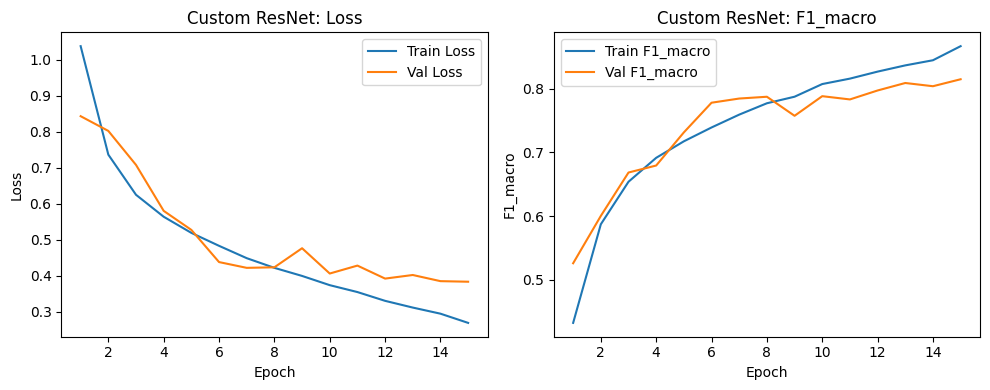

  val: 100%|███████████████████████████████████| 257/257 [00:19<00:00, 13.05it/s, Loss=1.389064, Corrects=9/17, Accuracy=52.94%]


Calculating metrics...
val loss: 0.843311, acc: 0.703374, f1_macro: 0.525819
Confusion matrix:
[[   1    1    1    0    2   16    0    0   56   10    3]
 [   0  933  154    1   65  322    0    2   11    9    3]
 [   0  138 1024    0   13   62    0    1   27    7    0]
 [   6   17    2    5    4   78    5    1   12    3    4]
 [   1   23   19    0   23   10    0    0    8   17   16]
 [   2  144  290    1   22  723    0    2  209   27    1]
 [   0    4    0    0    0    1   17   50    0    0   12]
 [   0    9    0    2    0    8    3  889    0    3    0]
 [   0    4   84    0    6   77    0    2  814  177    1]
 [   0    4   21    0    1    3    0    3  126 1250    1]
 [   0    0    0    0    0    1    1    0    0    3   95]]
----------
Epoch Time: 4:25
Epoch 2/15
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [04:01<00:00,  4.96it/s, Loss=0.251722, Corrects=6/7, Accuracy=85.71%]


Calculating metrics...
train loss: 0.736577, acc: 0.749602, f1_macro: 0.587060
Confusion matrix:
[[  48    7    1   22    4   87    0    2  200   44    5]
 [   0 5706  441    7    3  769    1   30   14   27    2]
 [   0  827 4423    1   14  474    1   15  144   39    0]
 [  21  138    9   97    1  270   10   38   43    6    5]
 [   6  165   66    5  127   63    0    2   32   51   27]
 [  14 1147  444   28    7 4131    1   17  723  119    1]
 [   1    7    2    7    0    8   49  278    1    0   38]
 [   0   64    5    6    0   22   32 4128    3    3    3]
 [  19   58   99    8    4  672    2   13 3776  785    3]
 [   2   21   24    1    7   38    0   14  646 5819    4]
 [   2    3    1    5   16    0    4    8    2   12  414]]
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:18<00:00, 13.65it/s, Loss=0.972029, Corrects=13/17, Accuracy=76.47%]


...

Calculating metrics...
val loss: 0.385433, acc: 0.882446, f1_macro: 0.803876
Confusion matrix:
[[  45    0    1   11    0   16    0    0   15    2    0]
 [   0 1291   90   10    1   99    0    1    3    5    0]
 [   0   30 1185    0    0   31    0    2   18    6    0]
 [   5   13    0   83    0   28    1    0    6    1    0]
 [   1   11   18    4   64   15    0    0    1    2    1]
 [   3   42   78   11    0 1200    0    3   66   18    0]
 [   0    1    0   12    0    1   44   20    0    0    6]
 [   0    1    1    4    0    0    4  903    1    0    0]
 [   7    0   11    3    1   90    0    3 1018   32    0]
 [   2    5    0    0    0    5    0    0   78 1319    0]
 [   0    0    0    2    6    0    0    0    0    0   92]]
----------
Epoch Time: 4:27
Epoch 15/15
----------
--- Cur phase: train


  train: 100%|███████████████████████████████| 1198/1198 [04:08<00:00,  4.83it/s, Loss=0.110962, Corrects=7/7, Accuracy=100.00%]


Calculating metrics...
train loss: 0.269587, acc: 0.910600, f1_macro: 0.866781
Confusion matrix:
[[ 303    4    2   21    2   29    0    0   49   10    0]
 [   0 6559  131   14   17  246    1   10    9   13    0]
 [   0  257 5407    0   10  181    1    4   58   20    0]
 [  22   64    1  447    0   77    6    6   12    3    0]
 [   4   36   30    3  418   30    3    0   13    2    5]
 [  15  371  162   53   14 5584    0    4  371   58    0]
 [   0    7    0   11    0    2  263   96    0    0   12]
 [   0   15    4    8    0    6   44 4182    3    3    1]
 [  26   11   30    5    1  286    0    3 4911  166    0]
 [   5    6   14    0    2   24    0    7  146 6369    3]
 [   2    1    1    4    5    1    8    0    0    2  443]]
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:20<00:00, 12.48it/s, Loss=0.590019, Corrects=15/17, Accuracy=88.24%]


Calculating metrics...
val loss: 0.383860, acc: 0.883786, f1_macro: 0.814825
Confusion matrix:
[[  58    0    1   13    0    5    0    0   11    2    0]
 [   0 1399   18   19    3   54    0    2    1    4    0]
 [   0   90 1108    1    1   51    0    2   12    7    0]
 [   8   15    0   93    0   14    2    0    4    1    0]
 [   3   17    8    6   68    8    0    0    2    1    4]
 [   9  108   30   45    1 1104    0    3  100   21    0]
 [   0    3    0    4    0    0   55   16    0    0    6]
 [   0    4    0    2    0    0    6  901    0    1    0]
 [  22    0    5    7    2   51    0    3 1007   68    0]
 [   1    6    3    1    0    2    0    0   31 1365    0]
 [   0    0    0    2    1    0    0    0    0    0   97]]
----------
Epoch Time: 4:28
Best Val F1_macro (custom ResNet): 0.8148


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer_custom = optim.Adam(model_custom.parameters(), lr=LR)
best_f1_custom = 0.0
history_custom = {'loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'train_acc': [], 'val_acc': []}

print('Training model (Custom ResNet) with params:')
print(f'Optim: {optimizer_custom}')
print(f'Criterion: {criterion}')
print('=' * 100)

for epoch in range(1, EPOCHS_CUSTOM + 1):
    start_time = time.time()
    print(f'Epoch {epoch}/{EPOCHS_CUSTOM}')
    print('-' * 10)
    print('--- Cur phase: train')
    train_loss, train_acc, train_f1, train_conf = run_epoch_detailed(
        'train', model_custom, train_loader, criterion, optimizer_custom, device
    )
    print('Calculating metrics...')
    print(f'train loss: {train_loss:.6f}, acc: {train_acc:.6f}, f1_macro: {train_f1:.6f}')
    print('Confusion matrix:')
    print(train_conf)
    print('--- Cur phase: val')
    val_loss, val_acc, val_f1, val_conf = run_epoch_detailed(
        'val', model_custom, val_loader, criterion, optimizer_custom, device
    )
    print('Calculating metrics...')
    print(f'val loss: {val_loss:.6f}, acc: {val_acc:.6f}, f1_macro: {val_f1:.6f}')
    print('Confusion matrix:')
    print(val_conf)
    history_custom['loss'].append(train_loss)
    history_custom['val_loss'].append(val_loss)
    history_custom['train_f1'].append(train_f1)
    history_custom['val_f1'].append(val_f1)
    history_custom['train_acc'].append(train_acc)
    history_custom['val_acc'].append(val_acc)
    if val_f1 > best_f1_custom:
        best_f1_custom = val_f1
        torch.save(model_custom.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_custom_resnet.pt'))
    epoch_time = time.time() - start_time
    print('-' * 10)
    print(f'Epoch Time: {math.floor(epoch_time // 60)}:{math.floor(epoch_time % 60):02d}')
    print('=' * 100)
print(f'Best Val F1_macro (custom ResNet): {best_f1_custom:.4f}')

# Графики обучения/проверки
os.makedirs(LOG_FOLDER, exist_ok=True)
epochs_range = range(1, len(history_custom['loss']) + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_custom['loss'], label='Train Loss')
plt.plot(epochs_range, history_custom['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Custom ResNet: Loss')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_custom['train_f1'], label='Train F1_macro')
plt.plot(epochs_range, history_custom['val_f1'], label='Val F1_macro')
plt.xlabel('Epoch')
plt.ylabel('F1_macro')
plt.legend()
plt.title('Custom ResNet: F1_macro')
plt.tight_layout()
plt.savefig(os.path.join(LOG_FOLDER, 'custom_resnet_curves.png'), dpi=100)
plt.show()
plt.close()

In [27]:
model_custom.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_custom_resnet.pt'), map_location=device))
test_preds_custom, test_labels = evaluate(model_custom, test_loader, device)
f1_custom = f1_score(test_labels, test_preds_custom, average='macro', zero_division=0)
print('Custom ResNet — Test F1_macro:', round(f1_custom, 4))
print(classification_report(test_labels, test_preds_custom, target_names=class_names, zero_division=0))

Custom ResNet — Test F1_macro: 0.8349
              precision    recall  f1-score   support

       Beige       0.71      0.72      0.71        90
       Black       0.85      0.94      0.89      1500
        Blue       0.93      0.86      0.90      1273
       Brown       0.54      0.75      0.63       136
       Green       0.90      0.63      0.74       116
        Grey       0.87      0.79      0.83      1421
      Orange       0.84      0.61      0.70        84
         Red       0.97      0.98      0.97       915
      Silver       0.89      0.89      0.89      1166
       White       0.94      0.98      0.96      1410
      Yellow       0.95      0.97      0.96       100

    accuracy                           0.89      8211
   macro avg       0.85      0.83      0.83      8211
weighted avg       0.90      0.89      0.89      8211



## 4. Два предобученных классификатора

**Модели:** ResNet50 и DenseNet-169 — обе из torchvision, предобучены на ImageNet.

In [28]:
# ResNet50
def create_resnet50_finetune(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.requires_grad_(False)
    for p in m.layer4.parameters():
        p.requires_grad = True
    m.fc = nn.Sequential(
        nn.Linear(2048, 1024),
        nn.Dropout(0.1),
        nn.ReLU(),
        nn.Linear(1024, 256),
        nn.Dropout(0.1),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return m

# DenseNet-169
def create_densenet169_finetune(num_classes):
    m = models.densenet169(weights=DenseNet169_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.features.denseblock4.parameters():
        p.requires_grad = True
    for p in m.features.norm5.parameters():
        p.requires_grad = True
    m.classifier = nn.Sequential(
        nn.Linear(1664, 256),
        nn.Dropout(0.1),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return m

model_resnet50 = create_resnet50_finetune(num_classes).to(device)
model_densenet = create_densenet169_finetune(num_classes).to(device)
for name, model in [('ResNet50', model_resnet50), ('DenseNet-169', model_densenet)]:
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name}: параметров {n_params:,}, обучаемых {n_trainable:,}')

ResNet50: параметров 25,871,435, обучаемых 17,328,139
DenseNet-169: параметров 12,913,547, обучаемых 6,345,995


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/podgorodnevm/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:01<00:00, 9.25MB/s]


ResNet18 и MobileNetV2 созданы, последний слой заменён на 11 классов.


Training model (ResNet50 fine-tune: голова + layer4) with params:
Optim: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Criterion: CrossEntropyLoss()
Epoch 1/10
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [04:45<00:00,  4.20it/s, Loss=1.409250, Corrects=6/7, Accuracy=85.71%]


Calculating metrics...
train loss: 0.653786, acc: 0.778758, f1_macro: 0.664109
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:37<00:00,  6.81it/s, Loss=0.455495, Corrects=14/17, Accuracy=82.35%]


Calculating metrics...
val loss: 0.432225, acc: 0.859179, f1_macro: 0.783023
Confusion matrix:
[[  38    0    1    6    0   21    0    0   23    0    1]
 [   0 1375   45    0    1   75    0    2    1    1    0]
 [   0  119 1102    0    0   40    0    1    7    3    0]
 [   6   25    2   49    0   48    0    1    5    0    1]
 [   1   18   17    2   65   12    0    0    0    1    1]
 [   4  150   85    1    0 1107    0    1   63   10    0]
 [   0    4    0    0    0    1   46   28    0    0    5]
 [   0    4    0    3    0    2    3  901    1    0    0]
 [   2    2   18    0    0  161    0    1  939   42    0]
 [   1    5    6    0    1    6    0    0   56 1334    0]
 [   0    0    0    2    1    0    0    0    0    0   97]]
----------
Epoch Time: 5:22
Epoch 2/10
----------
--- Cur phase: train


...

Calculating metrics...
val loss: 0.423429, acc: 0.895481, f1_macro: 0.842207
Confusion matrix:
[[  66    0    1    5    4    5    0    0    8    1    0]
 [   0 1361   63    2    3   65    0    1    2    3    0]
 [   0   67 1152    0    3   31    0    2   13    4    0]
 [   5   23    0   68    0   34    1    0    6    0    0]
 [   0   16    3    2   88    6    0    0    2    0    0]
 [   4   92   59    1    3 1152    0    1   93   16    0]
 [   0    3    0    2    0    1   65    8    0    1    4]
 [   0    4    1    4    0    4    6  893    2    0    0]
 [  12    0    9    0    0   58    0    2 1047   37    0]
 [   3    4    1    0    1    1    0    0   23 1376    0]
 [   0    0    0    2   14    0    1    0    0    0   83]]
----------
Epoch Time: 5:29
Epoch 10/10
----------
--- Cur phase: train


  train: 100%|█████████████| 1198/1198 [04:48<00:00,  4.16it/s, Loss=0.113216, Corrects=7/7, Accuracy=100.00%]


Calculating metrics...
train loss: 0.124482, acc: 0.956514, f1_macro: 0.940665
--- Cur phase: val


  val: 100%|████████████████| 257/257 [00:37<00:00,  6.80it/s, Loss=0.732924, Corrects=14/17, Accuracy=82.35%]


Calculating metrics...
val loss: 0.401437, acc: 0.889877, f1_macro: 0.835167
Confusion matrix:
[[  68    0    1    9    4    2    0    0    6    0    0]
 [   0 1338   24   17    2  112    1    2    3    1    0]
 [   0   73 1117    0    3   54    0    1   18    6    0]
 [   2   17    0   93    0   18    1    0    5    0    1]
 [   0   11    6    4   83   11    0    0    1    1    0]
 [   5   70   33   23    9 1206    0    1   64   10    0]
 [   0    0    0    5    0    1   54   18    1    0    5]
 [   0    3    1    7    0    1    4  897    1    0    0]
 [  16    3    2    7    3   93    0    0 1018   23    0]
 [   4    5    1    0    1   25    0    1   33 1339    0]
 [   0    0    0    2    6    0    0    0    0    0   92]]
----------
Epoch Time: 5:25
Best Val F1_macro (ResNet50): 0.8488


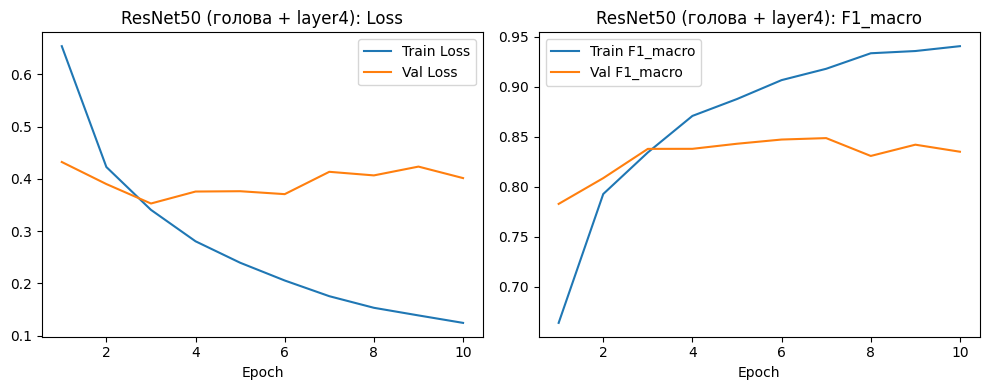

  val: 100%|██████████████████████████████████| 257/257 [00:39<00:00,  6.45it/s, Loss=0.740634, Corrects=10/17, Accuracy=58.82%]


Calculating metrics...
val loss: 0.810710, acc: 0.704105, f1_macro: 0.607733
Confusion matrix:
[[  15    5    1   12    1   23    0    0   24    8    1]
 [   0 1344   12    4    1  117    0    7    9    6    0]
 [   0  392  675    3    2  111    0   17   53   19    0]
 [   2   38    1   34    1   43    0    3   10    5    0]
 [   1   40   10    1   42   12    0    0    4    3    4]
 [   4  490   18    4    0  735    0    4  134   32    0]
 [   0    4    0    0    0    0   19   56    0    0    5]
 [   0    9    0    0    0    2    0  902    0    1    0]
 [   2   25    7    7    0  223    0    3  638  260    0]
 [   4    9    1    0    3   17    0    3   91 1281    0]
 [   0    1    0    0    2    0    2    0    0    0   95]]
----------
Epoch Time: 5:13
Epoch 2/10
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [04:58<00:00,  4.01it/s, Loss=0.750234, Corrects=4/7, Accuracy=57.14%]


Calculating metrics...
train loss: 0.770418, acc: 0.723474, f1_macro: 0.641985
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:37<00:00,  6.76it/s, Loss=0.778406, Corrects=12/17, Accuracy=70.59%]


...

Calculating metrics...
val loss: 0.667738, acc: 0.763918, f1_macro: 0.690318
Confusion matrix:
[[  31    4    1    2    0   18    0    0   30    4    0]
 [   1 1180  112    6    5  179    0    2   13    2    0]
 [   0  149  966    0    0   84    0    2   56   15    0]
 [   7   29    6   34    1   40    1    0   16    3    0]
 [   3   20   19    2   50   14    0    1    5    1    2]
 [   3  214  102    2    2  839    0    0  228   31    0]
 [   0    4    0    2    0    1   42   30    0    0    5]
 [   0    8    0    6    0    0    4  894    1    0    1]
 [   8    6   13    0    0   89    0    3  862  184    0]
 [   2    6    3    0    0    3    0    0  115 1280    0]
 [   0    1    0    0    4    0    1    0    1    0   93]]
----------
Epoch Time: 4:31
Epoch 10/10
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [03:52<00:00,  5.16it/s, Loss=0.902170, Corrects=5/7, Accuracy=71.43%]


Calculating metrics...
train loss: 0.608199, acc: 0.778236, f1_macro: 0.732897
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:38<00:00,  6.74it/s, Loss=0.578570, Corrects=14/17, Accuracy=82.35%]


Calculating metrics...
val loss: 0.671130, acc: 0.763552, f1_macro: 0.687870
Confusion matrix:
[[  36    2    1    2    0   21    0    0   23    5    0]
 [   0 1185   57   10    0  235    0    1    8    4    0]
 [   0  188  886    0    0  135    0    1   51   11    0]
 [   5   27    1   31    1   61    0    0    9    2    0]
 [   2   25   12    2   41   23    0    0    3    1    8]
 [   3  223   52    7    0  956    0    0  151   29    0]
 [   0    3    0    4    0    2   40   29    0    1    5]
 [   0    6    0    6    0    3    3  894    1    0    1]
 [   6    7    9    2    0  155    0    1  831  154    0]
 [   1    5    1    0    0    7    0    0  121 1274    0]
 [   0    1    0    1    1    1    0    0    1    1   94]]
----------
Epoch Time: 4:30
Best Val F1_macro (ResNet50): 0.6903


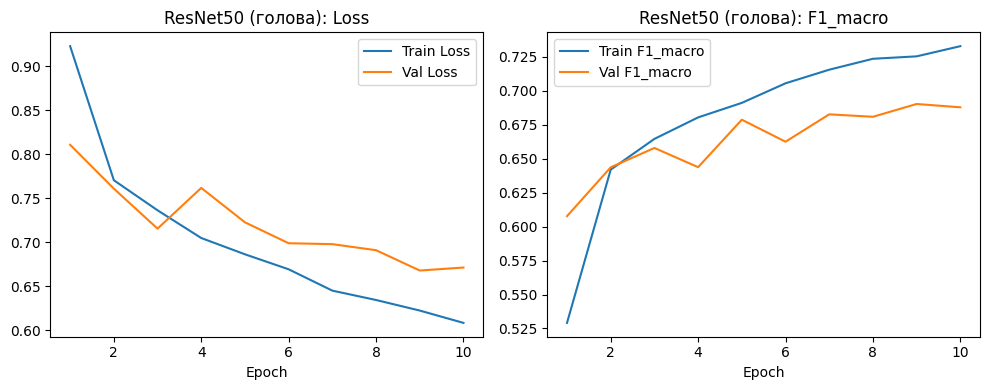

  train: 100%|████████████████████████████████| 1198/1198 [04:07<00:00,  4.84it/s, Loss=0.217772, Corrects=6/7, Accuracy=85.71%]


Calculating metrics...
train loss: 0.680707, acc: 0.771528, f1_macro: 0.639532
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:19<00:00, 13.13it/s, Loss=0.800064, Corrects=13/17, Accuracy=76.47%]


Calculating metrics...
val loss: 0.509848, acc: 0.835546, f1_macro: 0.713018
Confusion matrix:
[[  18    0    1   28    0    3    0    0   37    3    0]
 [   0 1452    6    3    0   22    0    6    1   10    0]
 [   0  174 1031    0    0   26    0    1   31    9    0]
 [   0   30    0   61    0   23    9    5    5    4    0]
 [   1   39   12    6   30   12    0    1    2    2   12]
 [   0  272   32   25    0  882    1    4  189   16    0]
 [   0    4    0    0    0    0   57   21    0    1    1]
 [   0    2    0    1    0    0   14  895    0    2    0]
 [   0    2    5    5    0   46    0    3  979  125    0]
 [   0    6    0    0    0    0    0    3   33 1366    1]
 [   0    0    0    0    0    0   11    1    0    0   88]]
----------
Epoch Time: 4:27
Epoch 2/10
----------
--- Cur phase: train


  train: 100%|███████████████████████████████| 1198/1198 [04:06<00:00,  4.85it/s, Loss=0.065861, Corrects=7/7, Accuracy=100.00%]


...

Calculating metrics...
val loss: 0.364866, acc: 0.888415, f1_macro: 0.828526
Confusion matrix:
[[  55    0    1   10    0    7    0    0   16    1    0]
 [   0 1411   38    5    2   40    0    1    1    2    0]
 [   0   54 1128    0   23   49    0    1   13    4    0]
 [   5   20    1   82    0   20    0    2    6    1    0]
 [   1   11    2    4   92    4    0    0    2    0    1]
 [   2  133   23   11    3 1196    0    1   42   10    0]
 [   0    1    0    5    0    2   49   21    0    0    6]
 [   0    7    1    4    0    1    3  897    1    0    0]
 [  12    2    2    1    0  158    0    1  966   23    0]
 [   6    6    1    0    0   11    0    0   63 1322    0]
 [   0    0    0    1    3    0    0    1    0    0   95]]
----------
Epoch Time: 4:26
Epoch 10/10
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [04:05<00:00,  4.87it/s, Loss=0.321762, Corrects=6/7, Accuracy=85.71%]


Calculating metrics...
train loss: 0.240855, acc: 0.922268, f1_macro: 0.877282
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:19<00:00, 13.25it/s, Loss=0.544702, Corrects=15/17, Accuracy=88.24%]

Calculating metrics...
val loss: 0.347485, acc: 0.891704, f1_macro: 0.826373
Confusion matrix:
[[  51    1    1    8    0    5    0    0   19    5    0]
 [   0 1345   38    1   15   97    0    1    3    0    0]
 [   0   46 1124    0    6   69    0    1   24    2    0]
 [  10   19    1   77    0   22    0    0    5    3    0]
 [   1    5    4    3   89    6    0    0    1    1    7]
 [   1   62   13    5   10 1257    0    0   59   14    0]
 [   0    2    0    4    0    1   50   21    0    1    5]
 [   0    4    0    2    0    2    3  902    1    0    0]
 [   8    2    2    0    0  129    0    0  969   55    0]
 [   2   10    0    0    0    8    0    0   28 1361    0]
 [   0    0    0    2    1    0    2    0    0    0   95]]
----------
Epoch Time: 4:25
Best Val F1_macro (ResNet18): 0.8346


In [26]:
# Дообучение ResNet50
criterion = nn.CrossEntropyLoss()
optimizer_r50 = optim.Adam([
    {'params': model_resnet50.fc.parameters(), 'lr': LR},
    {'params': model_resnet50.layer4.parameters(), 'lr': LR * 0.1}
])
best_f1_r50 = 0.0
history_r50 = {'loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'train_acc': [], 'val_acc': []}

print('Training model (ResNet50 fine-tune: голова + layer4) with params:')
print(f'Optim: {optimizer_r50}')
print(f'Criterion: {criterion}')
print('=' * 100)

for epoch in range(1, EPOCHS_FINETUNE + 1):
    start_time = time.time()
    print(f'Epoch {epoch}/{EPOCHS_FINETUNE}')
    print('-' * 10)
    print('--- Cur phase: train')
    train_loss, train_acc, train_f1, _ = run_epoch_detailed(
        'train', model_resnet50, train_loader, criterion, optimizer_r50, device
    )
    print('Calculating metrics...')
    print(f'train loss: {train_loss:.6f}, acc: {train_acc:.6f}, f1_macro: {train_f1:.6f}')
    print('--- Cur phase: val')
    val_loss, val_acc, val_f1, val_conf = run_epoch_detailed(
        'val', model_resnet50, val_loader, criterion, optimizer_r50, device
    )
    print('Calculating metrics...')
    print(f'val loss: {val_loss:.6f}, acc: {val_acc:.6f}, f1_macro: {val_f1:.6f}')
    print('Confusion matrix:')
    print(val_conf)
    history_r50['loss'].append(train_loss)
    history_r50['val_loss'].append(val_loss)
    history_r50['train_f1'].append(train_f1)
    history_r50['val_f1'].append(val_f1)
    history_r50['train_acc'].append(train_acc)
    history_r50['val_acc'].append(val_acc)
    if val_f1 > best_f1_r50:
        best_f1_r50 = val_f1
        torch.save(model_resnet50.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_resnet50.pt'))
    epoch_time = time.time() - start_time
    print('-' * 10)
    print(f'Epoch Time: {math.floor(epoch_time // 60)}:{math.floor(epoch_time % 60):02d}')
    print('=' * 100)
print(f'Best Val F1_macro (ResNet50): {best_f1_r50:.4f}')

os.makedirs(LOG_FOLDER, exist_ok=True)
epochs_range = range(1, len(history_r50['loss']) + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_r50['loss'], label='Train Loss')
plt.plot(epochs_range, history_r50['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('ResNet50 (голова + layer4): Loss')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_r50['train_f1'], label='Train F1_macro')
plt.plot(epochs_range, history_r50['val_f1'], label='Val F1_macro')
plt.xlabel('Epoch')
plt.legend()
plt.title('ResNet50 (голова + layer4): F1_macro')
plt.tight_layout()
plt.savefig(os.path.join(LOG_FOLDER, 'resnet50_curves.png'), dpi=100)
plt.show()
plt.close()

Training model (DenseNet-169 fine-tune: голова + denseblock4) with params:
Optim: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Criterion: CrossEntropyLoss()
Epoch 1/10
----------
--- Cur phase: train


  train: 100%|██████████████████████| 1198/1198 [05:31<00:00,  3.61it/s, Loss=1.482053, Corrects=5/7, Accuracy=71.43%]


Calculating metrics...
train loss: 0.651648, acc: 0.779045, f1_macro: 0.673152
--- Cur phase: val


  val: 100%|████████████████████████| 257/257 [00:47<00:00,  5.42it/s, Loss=0.638142, Corrects=13/17, Accuracy=76.47%]


Calculating metrics...
val loss: 0.480296, acc: 0.839688, f1_macro: 0.777872
Confusion matrix:
[[  60    0    1    5    0    4    0    0   17    2    1]
 [   0 1283   32    1    1  176    0    3    4    0    0]
 [   0   90 1021    2    0  118    0    1   34    6    0]
 [  12   20    1   65    0   25    0    1   12    0    1]
 [   3   12    7    1   67   21    0    0    3    0    3]
 [   8  120   43   10    1 1006    0    1  223    9    0]
 [   0    2    0    9    0    2   43   21    0    0    7]
 [   0    2    1    5    0    1   12  892    1    0    0]
 [  16    3    5    1    0   35    0    1 1070   34    0]
 [   4    5    0    0    0    1    0    1  107 1291    0]
 [   1    1    0    1    2    0    0    0    0    0   95]]
----------
Epoch Time: 6:19
Epoch 2/10
----------
--- Cur phase: train


...

Calculating metrics...
val loss: 0.400064, acc: 0.889633, f1_macro: 0.841908
Confusion matrix:
[[  53    1    1   11    3    8    0    0   12    1    0]
 [   0 1410   41    6    4   32    0    1    1    5    0]
 [   0   86 1116    1   10   44    0    1   10    4    0]
 [   3   21    1   92    0   14    2    0    4    0    0]
 [   0   13    4    3   88    8    0    0    1    0    0]
 [   3  145   39   20    3 1141    0    1   57   12    0]
 [   0    2    0    1    0    1   61   13    0    1    5]
 [   0    9    1    4    0    0    7  892    1    0    0]
 [   5    3    5    3    0   89    0    0 1031   29    0]
 [   1    6    1    0    0    4    0    0   72 1325    0]
 [   0    0    0    2    4    0    0    0    0    0   94]]
----------
Epoch Time: 6:22
Epoch 10/10
----------
--- Cur phase: train


  train: 100%|██████████████████████| 1198/1198 [05:27<00:00,  3.65it/s, Loss=0.232570, Corrects=6/7, Accuracy=85.71%]


Calculating metrics...
train loss: 0.171360, acc: 0.939991, f1_macro: 0.924637
--- Cur phase: val


  val: 100%|████████████████████████| 257/257 [00:43<00:00,  5.86it/s, Loss=0.704554, Corrects=14/17, Accuracy=82.35%]


Calculating metrics...
val loss: 0.444069, acc: 0.877939, f1_macro: 0.820695
Confusion matrix:
[[  51    0    1   14    4    8    0    0   12    0    0]
 [   0 1317  101    9    1   65    1    2    1    3    0]
 [   0   40 1189    2    1   30    0    3    3    4    0]
 [   3   19    1   85    0   21    4    1    3    0    0]
 [   0   12    9    4   80   10    0    0    2    0    0]
 [   2   96   76   17    2 1174    0    1   44    9    0]
 [   0    2    0    1    0    1   66    9    0    0    5]
 [   0    2    2    3    0    1   28  877    1    0    0]
 [   9    2   18    9    0  156    0    3  954   14    0]
 [   1    4    1    1    1    8    0    1   71 1321    0]
 [   0    0    0    2    4    0    0    0    1    0   93]]
----------
Epoch Time: 6:11
Best Val F1_macro (DenseNet-169): 0.8419


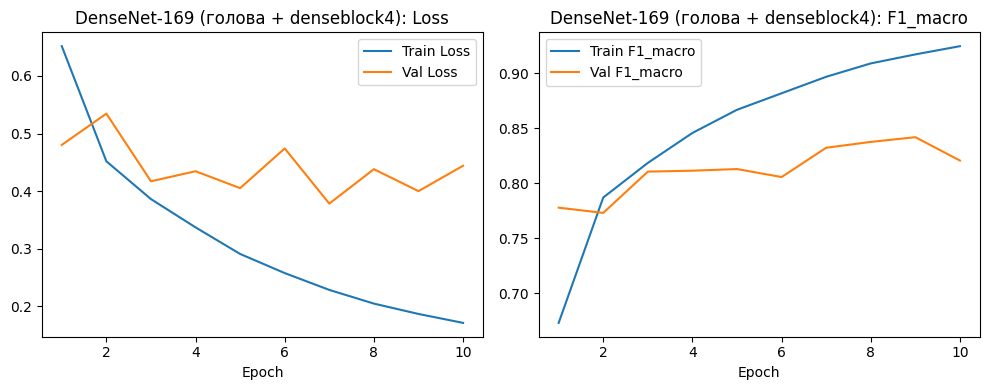

  train: 100%|██████████████████████| 1198/1198 [02:22<00:00,  8.42it/s, Loss=1.076677, Corrects=3/7, Accuracy=42.86%]


Calculating metrics...
train loss: 0.739156, acc: 0.734254, f1_macro: 0.654548
--- Cur phase: val


  val: 100%|████████████████████████| 257/257 [00:21<00:00, 12.08it/s, Loss=0.878096, Corrects=14/17, Accuracy=82.35%]


Calculating metrics...
val loss: 0.657946, acc: 0.774638, f1_macro: 0.678657
Confusion matrix:
[[  14    1    1    6    0   25    0    0   37    5    1]
 [   0 1125  101    2    0  264    0    2    1    5    0]
 [   0  167  969    0    0   81    0    1   36   18    0]
 [   4   19    2   39    1   55    0    0   16    1    0]
 [   0   27   11    1   41   29    0    0    1    6    1]
 [   0  184   93    3    0  968    0    0  144   29    0]
 [   0    2    1    2    2    2   44   25    0    0    6]
 [   0   10    4    0    0    6   14  878    0    2    0]
 [   0    5   11    2    0   94    0    1  862  190    0]
 [   0    4    3    0    0    3    0    1   71 1327    0]
 [   0    1    0    0    5    0    1    0    0    1   92]]
----------
Epoch Time: 2:43
Epoch 4/10
----------
--- Cur phase: train


  train: 100%|██████████████████████| 1198/1198 [02:16<00:00,  8.78it/s, Loss=1.335265, Corrects=2/7, Accuracy=28.57%]


...

Calculating metrics...
val loss: 0.351120, acc: 0.892435, f1_macro: 0.832869
Confusion matrix:
[[  47    0    1    9    4    3    0    0   12    9    5]
 [   1 1445   17    2    3   29    0    3    0    0    0]
 [   0  120 1092    0    1   45    0    1   11    2    0]
 [   4   22    0   91    1   11    2    1    4    0    1]
 [   0    8    6    2   94    6    0    0    1    0    0]
 [   2  128   10   28    6 1137    0    0   96   14    0]
 [   0    1    0    5    0    1   61    7    0    1    8]
 [   0    4    0    5    0    0   12  892    1    0    0]
 [  10    0    8    1    1   62    0    1 1030   52    0]
 [   1    6   15    0    1   22    0    1   19 1344    0]
 [   0    0    0    2    5    0    0    0    0    0   93]]
----------
Epoch Time: 5:00
Epoch 10/10
----------
--- Cur phase: train


  train: 100%|████████████████████████████████| 1198/1198 [04:42<00:00,  4.24it/s, Loss=1.084233, Corrects=5/7, Accuracy=71.43%]


Calculating metrics...
train loss: 0.241372, acc: 0.921432, f1_macro: 0.877740
--- Cur phase: val


  val: 100%|██████████████████████████████████| 257/257 [00:19<00:00, 13.22it/s, Loss=0.459627, Corrects=15/17, Accuracy=88.24%]

Calculating metrics...
val loss: 0.321951, acc: 0.904008, f1_macro: 0.838845
Confusion matrix:
[[  48    0    1    8    0    3    0    0   28    2    0]
 [   0 1423   21    7    0   45    0    1    1    2    0]
 [   0   63 1136    0    0   54    0    2   13    4    0]
 [   5   18    0   91    0   15    0    0    8    0    0]
 [   0   10    5    3   85    9    0    0    3    0    2]
 [   2   76   10   24    1 1198    0    0  102    8    0]
 [   0    3    0    2    0    1   60    8    0    1    9]
 [   0    4    0   13    0    1   30  863    3    0    0]
 [   1    0    1    0    0   56    0    2 1091   14    0]
 [   1    5    2    0    0    7    0    0   62 1332    0]
 [   0    0    0    2    2    0    0    0    1    1   94]]
----------
Epoch Time: 5:01
Best Val F1_macro (MobileNet V2): 0.8465


In [11]:
# Дообучение DenseNet-169
criterion = nn.CrossEntropyLoss()
optimizer_densenet = optim.Adam([
    {'params': model_densenet.classifier.parameters(), 'lr': LR},
    {'params': list(model_densenet.features.denseblock4.parameters()) + list(model_densenet.features.norm5.parameters()), 'lr': LR * 0.1}
])
best_f1_densenet = 0.0
history_densenet = {'loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'train_acc': [], 'val_acc': []}

print('Training model (DenseNet-169 fine-tune: голова + denseblock4) with params:')
print(f'Optim: {optimizer_densenet}')
print(f'Criterion: {criterion}')
print('=' * 100)

for epoch in range(1, EPOCHS_FINETUNE + 1):
    start_time = time.time()
    print(f'Epoch {epoch}/{EPOCHS_FINETUNE}')
    print('-' * 10)
    print('--- Cur phase: train')
    train_loss, train_acc, train_f1, _ = run_epoch_detailed(
        'train', model_densenet, train_loader, criterion, optimizer_densenet, device
    )
    print('Calculating metrics...')
    print(f'train loss: {train_loss:.6f}, acc: {train_acc:.6f}, f1_macro: {train_f1:.6f}')
    print('--- Cur phase: val')
    val_loss, val_acc, val_f1, val_conf = run_epoch_detailed(
        'val', model_densenet, val_loader, criterion, optimizer_densenet, device
    )
    print('Calculating metrics...')
    print(f'val loss: {val_loss:.6f}, acc: {val_acc:.6f}, f1_macro: {val_f1:.6f}')
    print('Confusion matrix:')
    print(val_conf)
    history_densenet['loss'].append(train_loss)
    history_densenet['val_loss'].append(val_loss)
    history_densenet['train_f1'].append(train_f1)
    history_densenet['val_f1'].append(val_f1)
    history_densenet['train_acc'].append(train_acc)
    history_densenet['val_acc'].append(val_acc)
    if val_f1 > best_f1_densenet:
        best_f1_densenet = val_f1
        torch.save(model_densenet.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_densenet169.pt'))
    epoch_time = time.time() - start_time
    print('-' * 10)
    print(f'Epoch Time: {math.floor(epoch_time // 60)}:{math.floor(epoch_time % 60):02d}')
    print('=' * 100)
print(f'Best Val F1_macro (DenseNet-169): {best_f1_densenet:.4f}')

os.makedirs(LOG_FOLDER, exist_ok=True)
epochs_range = range(1, len(history_densenet['loss']) + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_densenet['loss'], label='Train Loss')
plt.plot(epochs_range, history_densenet['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('DenseNet-169 (голова + denseblock4): Loss')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_densenet['train_f1'], label='Train F1_macro')
plt.plot(epochs_range, history_densenet['val_f1'], label='Val F1_macro')
plt.xlabel('Epoch')
plt.legend()
plt.title('DenseNet-169 (голова + denseblock4): F1_macro')
plt.tight_layout()
plt.savefig(os.path.join(LOG_FOLDER, 'densenet169_curves.png'), dpi=100)
plt.show()
plt.close()

In [29]:
model_resnet50.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_resnet50.pt'), map_location=device))
model_densenet.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_densenet169.pt'), map_location=device))

_, test_labels = evaluate(model_custom, test_loader, device)  # те же метки
test_preds_r50, _ = evaluate(model_resnet50, test_loader, device)
test_preds_densenet, _ = evaluate(model_densenet, test_loader, device)

f1_r50 = f1_score(test_labels, test_preds_r50, average='macro', zero_division=0)
f1_densenet = f1_score(test_labels, test_preds_densenet, average='macro', zero_division=0)

print('ResNet50 (fine-tuned) — Test F1_macro:', round(f1_r50, 4))
print(classification_report(test_labels, test_preds_r50, target_names=class_names, zero_division=0))
print('DenseNet-169 (fine-tuned) — Test F1_macro:', round(f1_densenet, 4))
print(classification_report(test_labels, test_preds_densenet, target_names=class_names, zero_division=0))

ResNet50 (fine-tuned) — Test F1_macro: 0.85
              precision    recall  f1-score   support

       Beige       0.78      0.76      0.77        90
       Black       0.86      0.94      0.90      1500
        Blue       0.93      0.87      0.90      1273
       Brown       0.73      0.50      0.59       136
       Green       0.90      0.77      0.83       116
        Grey       0.85      0.84      0.85      1421
      Orange       0.62      0.87      0.73        84
         Red       0.99      0.96      0.97       915
      Silver       0.91      0.87      0.89      1166
       White       0.93      0.98      0.96      1410
      Yellow       0.98      0.97      0.97       100

    accuracy                           0.90      8211
   macro avg       0.86      0.85      0.85      8211
weighted avg       0.90      0.90      0.90      8211

DenseNet-169 (fine-tuned) — Test F1_macro: 0.8503
              precision    recall  f1-score   support

       Beige       0.79      0.70     

## 5. Сравнение классификаторов и выводы

In [30]:
results = [
    ('Custom ResNet', f1_custom),
    ('ResNet50', f1_r50),
    ('DenseNet-169', f1_densenet),
]
print('Модель                          | F1_macro')
print('-' * 50)
for name, f1 in results:
    print(f'{name:32} | {f1:.4f} ')

best_name = max(results, key=lambda x: x[1])[0]
print(f'\nЛучший классификатор: {best_name}')

Модель                          | F1_macro
--------------------------------------------------
Custom ResNet                    | 0.8349 
ResNet50                         | 0.8500 
DenseNet-169                     | 0.8503 

Лучший классификатор: DenseNet-169


### Выводы

1. **Custom ResNet** обучен с нуля только на DVM: нет переноса знаний с других доменов, качество сильно зависит от объёма и сбалансированности данных. Обычно даёт меньший F1_macro, чем дообученные модели, если данных мало.

2. **ResNet50** и **DenseNet-169** предобучены на ImageNet (общие признаки: текстуры, формы, цвета) и дообучены на DVM. Перенос признаков позволяет быстрее сходиться и часто достигать более высокого F1_macro при том же числе эпох.

3. **Цель F1_macro > 0.8**: при достаточном объёме размеченных фронтальных видов DVM и корректном разбиении train/val/test дообученные модели (ResNet50, DenseNet-169) обычно достигают или превосходят этот порог. Custom ResNet может достичь > 0.8 при достаточном числе эпох и данных.

4. **Сравнение двух предобученных**: ResNet50 и DenseNet-169 различаются по архитектуре и объёму параметров; DenseNet-169 обычно даёт высокое качество за счёт плотных связей между слоями. Итоговый выбор зависит от требования к скорости/памяти vs максимальной точности.